## A/B Testing

### Random Sampling

In [1]:
import numpy as np
import pandas as pd

from itertools import combinations

rng =np.random.default_rng(42)

df_sampling = pd.DataFrame(
    {
        "user_id": np.arange(1, 101),
        "category": rng.choice(["A", "B", "C"], size = 100, p=[0.5, 0.3, 0.2]),
        "score": rng.normal(loc=75, scale=10, size=100).round(2),
    }
)

In [2]:
print(f'The shape of the Dataframe: {df_sampling.shape}')
print(f'The columns of the Dataframe: {df_sampling.columns}')
df_sampling.head()

The shape of the Dataframe: (100, 3)
The columns of the Dataframe: Index(['user_id', 'category', 'score'], dtype='str')


,user_id,category,score
0,1,B,79.00
1,2,A,65.95
2,3,C,71.22
3,4,B,87.99
4,5,A,71.44


In [3]:
df_sampling['score'].describe()[['mean', 'std', 'min', 'max']]

mean     74.859800
std       9.843752
min      53.680000
max     104.140000
Name: score, dtype: float64

In [4]:
df_sampling['category'].value_counts().sort_index()

category
A    53
B    33
C    14
Name: count, dtype: int64

In [5]:
df_sampling.groupby('category')['score'].describe()[['mean', 'std', 'min', 'max']]

,mean,std,min,max
category,,,,
A,74.200000,8.973076,60.29,94.97
B,76.272424,10.014058,58.25,96.28
C,74.027857,12.705514,53.68,104.14


### Random Sampling

In [6]:
random_sample = df_sampling.sample(n=20, random_state=42)
random_sample.shape

(20, 3)

In [7]:
random_sample.groupby('category')['score'].describe()[['mean', 'std', 'min', 'max']]

,mean,std,min,max
category,,,,
A,71.211250,8.747513,61.23,83.40
B,75.071429,6.553916,64.64,83.38
C,67.838000,10.015841,53.68,77.68


In [8]:
random_sample['category'].value_counts().sort_index()

category
A    8
B    7
C    5
Name: count, dtype: int64

### Stratified Sampling

In [10]:
stratified_sample = (
    df_sampling
    .groupby("category", group_keys=False)
    .sample(frac=0.2,random_state=42)
    .reset_index(drop=True)
)

In [11]:
stratified_sample.head()

,user_id,category,score
0,39,A,78.14
1,84,A,77.19
2,93,A,92.24
3,29,A,89.63
4,86,A,86.06


In [13]:
stratified_sample.groupby('category')['score'].describe()[['mean', 'std', 'min', 'max']]

,mean,std,min,max
category,,,,
A,76.688182,10.510287,60.29,92.24
B,78.715714,10.081969,66.79,92.68
C,63.650000,5.447054,57.73,68.45


In [14]:
stratified_sample['category'].value_counts().sort_index()

category
A    11
B     7
C     3
Name: count, dtype: int64

In [15]:
df_sampling['category'].value_counts(normalize=True).sort_index()

category
A    0.53
B    0.33
C    0.14
Name: proportion, dtype: float64

### Stratified Sampling | Equal number of samples from each category


In [17]:
stratified_sample = (
    df_sampling
    .groupby("category", group_keys=False)
    .sample(n=10, random_state=42)
    .reset_index(drop=True))

### Splitting the data into control and treatment groups

#### Pure Random Splitting

In [18]:
rng = np.random.default_rng(42)
df_random_split = df_sampling.assign(
    group=rng.choice(['control', 'treatment'], size=len(df_sampling)))

df_random_split['group'].value_counts()

group
treatment    52
control      48
Name: count, dtype: int64

#### Stratified Splitting

In [19]:
df_stratified_split = (
    df_sampling
    .assign(
        group=lambda x: (
            x.groupby('category')['user_id']
            .transform(
                lambda g: rng.permutation(
                    ['control']*(len(g)//2)+
                    ['treatment'] * (len(g) - len(g)//2)
                )
            )
        )
    )
)

df_stratified_split[['group', 'category']].value_counts()

group      category
treatment  A           27
control    A           26
treatment  B           17
control    B           16
treatment  C            7
control    C            7
Name: count, dtype: int64

### Analyzing the results

#### Import Packages

In [23]:
import numpy as np 
import pandas as pd
import math
from statsmodels.stats.power import TTestIndPower
from statsmodels.stats.multitest import multipletests
from scipy.stats import ttest_ind
import scipy
import matplotlib.pyplot as plt

In [24]:
N = TTestIndPower().solve_power(effect_size = 0.4, power = 0.8, alpha = 0.05)
print(N)

99.08032514676705


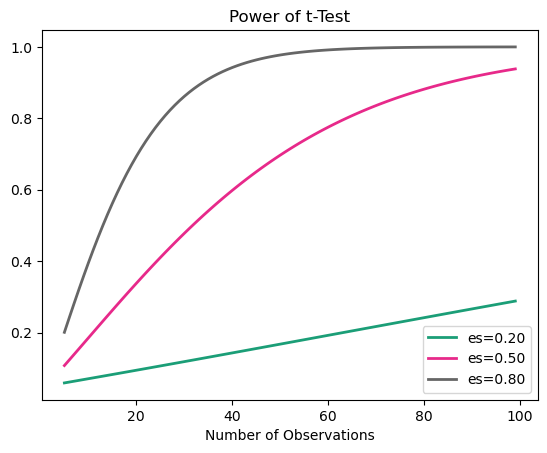

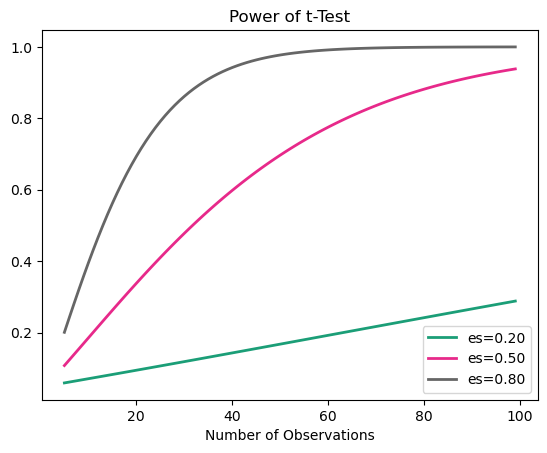

In [25]:
TTestIndPower().plot_power(dep_var='nobs',
                           nobs=np.array(range(5,100)),
                           effect_size=np.array([0.2, 0.5, 0.8]),
                           title='Power of t-Test')

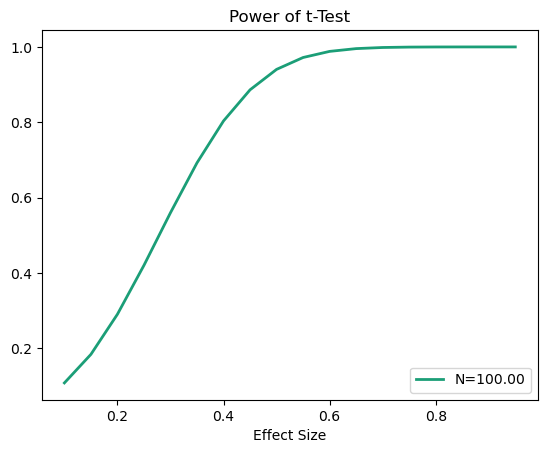

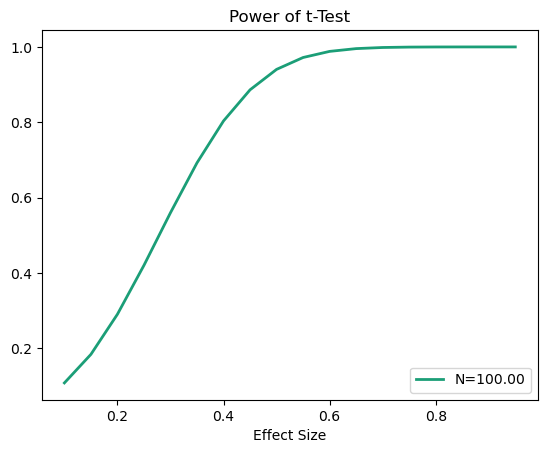

In [28]:
TTestIndPower().plot_power(dep_var='effect_size', nobs= [100],
                           effect_size=np.arange(0.1, 1, 0.05),
                           title='Power of t-Test')

In [29]:
TTestIndPower().solve_power(effect_size=0.365, power = 0.8,
                            alpha = 0.05, alternative = 'larger')

93.4975695136995

In [31]:
URL = 'https://raw.githubusercontent.com/hovhannisyan91/aca/refs/heads/main/lab/python/data/ab_testing/experiment.csv'
expr = pd.read_csv(URL)

In [32]:
expr.head()

,user_id,viewing_time,Group
0,4b5630ee914e848e8d07221556b0a2fb,38.354937,control
1,c01f179e4b57ab8bd9de309e6d576c48,49.534278,control
2,11946e7a3ed5e1776e81c0f0ecd383d0,35.468325,control
3,234a2a5581872457b9fe1187d1616b13,69.014875,control
4,dd4ad37ee474732a009111e3456e7ed7,51.547207,control


In [33]:
expr.groupby('Group')['viewing_time'].mean()

Group
control      48.386186
treatment    52.081302
Name: viewing_time, dtype: float64

#### T-test

In [37]:
ctrl = expr[expr['Group'] == 'control']['viewing_time']
treatment = expr[expr['Group'] == 'treatment']['viewing_time']

test_res = ttest_ind(treatment, ctrl)
tstat, pvalue = test_res

print(f"t-statistics: {tstat:.4f}")
print(f"p-value: {pvalue:.4f}")

t-statistics: 1.6002
p-value: 0.1128


#### Cohen's d

In [38]:
diff = treatment.mean() - ctrl.mean()
sd_pooled = math.sqrt((treatment.std()**2 + ctrl.std()**2) / 2)

print(f"The detected Effect: {diff/sd_pooled:.4f}")

The detected Effect: 0.3200


### Utils Functions

In [47]:
def measures(data):
    desc = data.describe()
    x1 = desc.loc['mean', 'score1']
    x2 = desc.loc['mean', 'score2']
    s1 = desc.loc['std', 'score1']
    s2 = desc.loc['std', 'score2']
    return x1, x2, s1, s2

def ttest(x1, x2, s1, s2, n):
    t_value = (x1 - x2) / math.sqrt(s1**2 / n + s2**2 / n)
    p_value = scipy.stats.t.sf(abs(t_value), df=n-1) * 2
    return f't-value: {t_value:.4f}', f'p-value {p_value:.4f}'

#### Case 1 | Low Variance

In [40]:
URL = 'https://raw.githubusercontent.com/hovhannisyan91/aca/refs/heads/main/lab/python/data/ab_testing/case1.csv'
case1 = pd.read_csv(URL)

In [41]:
case1.head()

,score1,score2
0,85,87
1,85,86
2,86,87
3,86,86
4,85,86


In [42]:
case1.describe().loc[['count', 'mean', 'std']]

,score1,score2
count,20.000000,20.000000
mean,85.550000,86.400000
std,0.510418,0.502625


In [49]:
c1 = measures(case1)
ttest(*c1, 20)

('t-value: -5.3065', 'p-value 0.0000')

#### Case 2 | Huge Sample Size 

In [44]:
URL = 'https://raw.githubusercontent.com/hovhannisyan91/aca/refs/heads/main/lab/python/data/ab_testing/case2.csv'
case2 = pd.read_csv(URL)
case2.head()

,score1,score2
0,88,95
1,89,88
2,91,93
3,94,87
4,87,89


In [45]:
case2.describe().loc[['count', 'mean', 'std']]

,score1,score2
count,20.000000,20.000000
mean,90.650000,90.750000
std,2.777257,2.788605


In [50]:
c2 = measures(case2)

print(ttest(*c2, 200))

print(ttest(*c2, 2000))

print(ttest(*c2, 20000))

('t-value: -0.3593', 'p-value 0.7197')
('t-value: -1.1363', 'p-value 0.2560')
('t-value: -3.5933', 'p-value 0.0003')
